# 03 - Modelagem

Comparação de três algoritmos com duas regras simples (baselines). Tudo prevê a variação de preço
3 meses à frente; as métricas são calculadas no preço em dólar.

**Separação temporal:** treino = alvos até dez/2024; teste = previsões feitas a partir de dez/2024
(alvos de mar/2025 a jul/2026). Nenhum preço usado no treino é posterior ao mês-base do teste.

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")

from src.config import ARQUIVO_MODELAGEM, FIM_TREINO, FIGURES_DIR
from src.models.train_model import criar_modelos, separar_treino_teste, FEATURES
from src.models.evaluate import prever_todos, calcular_metricas, metricas_por_grupo

In [2]:
base = pd.read_parquet(ARQUIVO_MODELAGEM)
treino, teste = separar_treino_teste(base, FIM_TREINO)
print(f"Treino: {len(treino)} linhas | alvo de {treino['data_alvo'].min().date()} a {treino['data_alvo'].max().date()}")
print(f"Teste:  {len(teste)} linhas | alvo de {teste['data_alvo'].min().date()} a {teste['data_alvo'].max().date()}")

Treino: 5912 linhas | alvo de 2016-04-01 a 2024-12-01
Teste:  943 linhas | alvo de 2025-03-01 a 2026-07-01


## Modelos

- **ingenuo**: o preço daqui a 3 meses é o de hoje.
- **sazonal_ingenuo**: repete a variação que houve na mesma janela do ano passado.
- **ridge**: regressão linear regularizada, com features padronizadas.
- **random_forest** e **gradient_boosting**: árvores, capturam interações (ex.: sazonalidade só importa para frutas).

Um único modelo é treinado para as 60 séries. A escala não atrapalha porque o alvo é variação percentual.

In [3]:
modelos = criar_modelos()
for nome, m in modelos.items():
    m.fit(treino[FEATURES], treino["alvo"])
    print(nome, "ok")

ridge ok


random_forest ok


gradient_boosting ok


## Resultado no teste

In [4]:
prev = prever_todos(teste, modelos)
metricas = calcular_metricas(prev).sort_values("wape")
metricas

,modelo,mae_usd,mape,wape,vies_pct,ganho_vs_ingenuo_pct,series_melhor_que_ingenuo_pct
2,random_forest,0.177,3.880,3.853,-0.342,10.068,73.333
0,gradient_boosting,0.179,3.840,3.896,-0.612,9.059,68.333
3,ridge,0.195,4.248,4.237,-0.056,1.104,53.333
1,ingenuo,0.197,4.294,4.284,-0.807,0.000,NaN
4,sazonal_ingenuo,0.233,5.159,5.065,-0.007,-18.239,21.667


- `wape`: erro absoluto total / valor total real (%). É a métrica principal: não explode em itens baratos como o MAPE.
- `ganho_vs_ingenuo_pct`: quanto o WAPE caiu em relação ao ingênuo.
- `series_melhor_que_ingenuo_pct`: em quantas das 60 séries o modelo erra menos que o ingênuo.

In [5]:
cat = metricas_por_grupo(prev, "categoria").pivot(index="categoria", columns="modelo", values="wape")
cat = cat[["ingenuo", "sazonal_ingenuo", "ridge", "random_forest", "gradient_boosting"]]
cat["ganho_gb_%"] = (1 - cat["gradient_boosting"] / cat["ingenuo"]) * 100
cat.sort_values("ganho_gb_%", ascending=False).round(2)

modelo,ingenuo,sazonal_ingenuo,ridge,random_forest,gradient_boosting,ganho_gb_%
categoria,,,,,,
Frutas,6.71,4.79,4.70,4.40,3.82,43.06
Ovos,24.05,38.72,24.58,22.76,20.40,15.19
Carne bovina,4.05,4.23,3.75,3.35,3.52,12.99
Suínos e frios,2.37,2.86,2.46,2.18,2.14,9.70
Hortaliças,6.70,7.80,6.38,5.93,6.05,9.60
Energia,8.85,10.37,8.72,8.52,8.48,4.10
Mercearia,4.00,5.23,4.68,3.80,4.02,-0.70
Laticínios,3.07,4.48,3.41,3.18,3.20,-4.24
Aves,1.16,2.49,1.61,1.07,1.22,-4.99


## O que o modelo está usando

Importância por permutação no teste: quanto o erro piora quando embaralhamos cada feature.

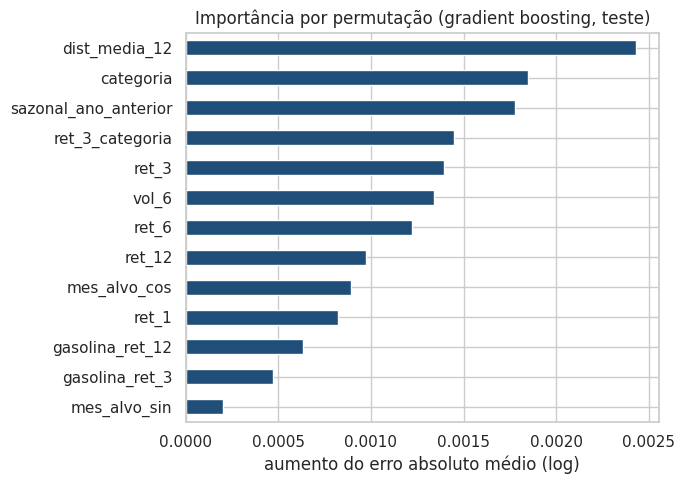

In [6]:
from sklearn.inspection import permutation_importance

gb = modelos["gradient_boosting"]
imp = permutation_importance(gb, teste[FEATURES], teste["alvo"], n_repeats=10, random_state=42,
                             scoring="neg_mean_absolute_error")
imp = pd.Series(imp.importances_mean, index=FEATURES).sort_values()
ax = imp.plot(kind="barh", figsize=(7, 5), color="#1f4e79")
ax.set_title("Importância por permutação (gradient boosting, teste)")
ax.set_xlabel("aumento do erro absoluto médio (log)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_importancia_features.png", dpi=120)

## Onde o modelo mais ganha e mais perde

In [7]:
por_item = prev.groupby(["item", "modelo"])["erro_abs"].mean().unstack()
por_item["razao"] = por_item["gradient_boosting"] / por_item["ingenuo"]
pd.concat([por_item.nsmallest(6, "razao"), por_item.nlargest(6, "razao")])[["ingenuo", "gradient_boosting", "razao"]].round(3)

modelo,ingenuo,gradient_boosting,razao
item,,,
"Strawberries, dry pint",0.456,0.168,0.367
"Oranges, Navel",0.113,0.049,0.435
"Sugar, white, all sizes",0.024,0.016,0.656
All Ham (Excluding Canned Ham and Luncheon Slices),0.094,0.072,0.770
All Uncooked Other Beef (Excluding Veal),0.314,0.247,0.785
"Steak, sirloin, USDA Choice, boneless",0.628,0.501,0.797
"Wine, red and white table, all sizes, any origin",0.180,0.269,1.494
"Chicken, fresh, whole",0.016,0.021,1.318
"Beans, dried, any type, all sizes",0.044,0.056,1.271


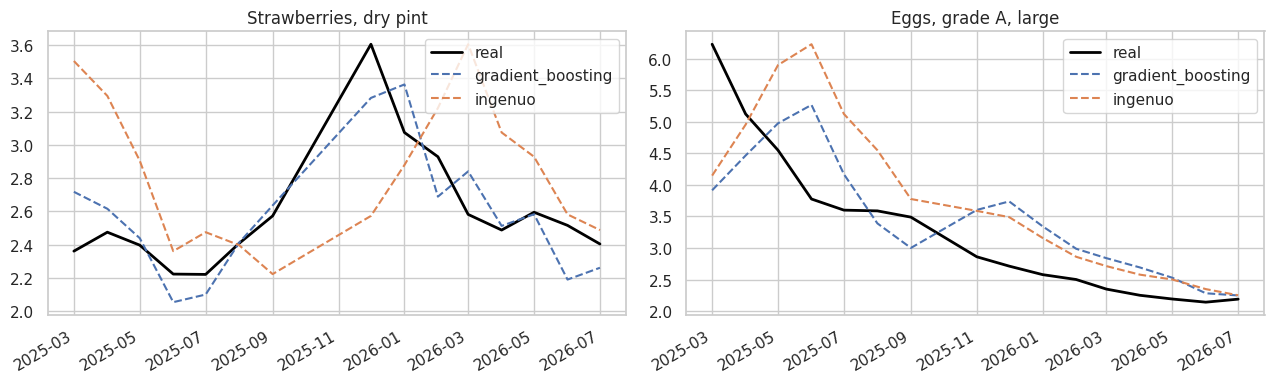

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)
for ax, item in zip(axes, ["Strawberries, dry pint", "Eggs, grade A, large"]):
    d = prev[(prev["item"] == item) & prev["modelo"].isin(["ingenuo", "gradient_boosting"])]
    real = d.drop_duplicates("data_alvo").set_index("data_alvo")["preco_real"]
    real.plot(ax=ax, color="black", lw=2, label="real")
    for nome, g in d.groupby("modelo"):
        g.set_index("data_alvo")["preco_previsto"].plot(ax=ax, ls="--", label=nome)
    ax.set_title(item)
    ax.set_xlabel("")
    ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_exemplos_previsao.png", dpi=120)

No morango o modelo acerta o formato da curva (sazonalidade), enquanto o ingênuo fica sempre 3 meses atrasado. Nos ovos, os dois sofrem na queda depois do pico de março/2025; o modelo corrige mais rápido porque `dist_media_12` indica que o preço está muito acima da média recente.

As features mais usadas são justamente essas: distância da média de 12 meses (reversão), categoria e o que aconteceu no ano anterior (sazonalidade). A gasolina entra, mas com peso baixo, como a EDA já indicava.